Analyze the proteome for the E. coli core model
- Map measured protein abundaces to model genes/enzymes

In [38]:
import pandas as pd
import cobra
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assign subcellular location to each gene

### Assign uniprotid to each gene in the extracted proteome set

                   SP4+TX100_avg_per_cell [fg] Uniprot Accession  \
Bnumber uniprotID                                                  
b4595   A5A613                        0.000704            A5A613   
b4606   A5A621                        0.000098            A5A621   
b4407   O32583                        0.000608            O32583   
b2636   O52982                        0.005375            O52982   
b1667   P0ACX3                        0.001992            P0ACX3   
...                                        ...               ...   
b2745   Q57261                        0.095464            Q57261   
b0484   Q59385                        0.260373            Q59385   
b0066   P31548                        0.005513            P31548   
b1172   Q7DFV3                        0.014304            Q7DFV3   
b0855   P31134                        0.051908            P31134   

                  Cellular protein location  
Bnumber uniprotID                            
b4595   A5A613         

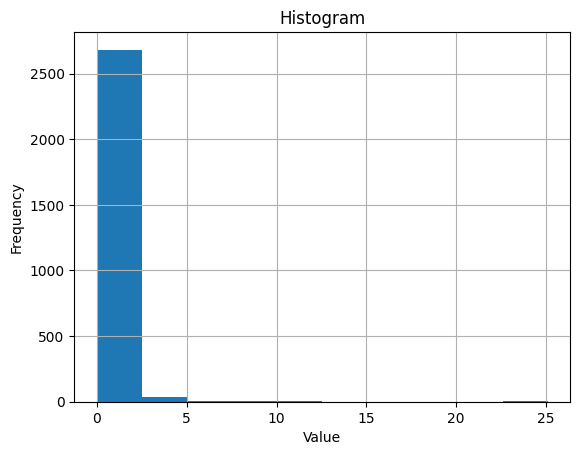

In [39]:
proteome_df = pd.read_excel('../Data/proteome_data_extract_shannara2024.xlsx',
                            sheet_name='ProteinMasses',
                            engine='openpyxl')

protein2location_df = pd.read_excel('../Data/proteome_data_extract_shannara2024.xlsx',
                            sheet_name='SubcellularLocation',
                            engine='openpyxl')

proteome_df = pd.merge(left=proteome_df,
                       right=protein2location_df,
                       how='left',
                       left_on='uniprotID',
                       right_on='Uniprot Accession')

proteome_df = proteome_df.set_index(["Bnumber", "uniprotID"])
print(proteome_df)
print(proteome_df.shape)

proteome_df['SP4+TX100_avg_per_cell [fg]'].hist()

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()


# Load proteome data
## Protein abundances

In [40]:
proteome_df = proteome_df
print(proteome_df.sum(numeric_only=True))


SP4+TX100_avg_per_cell [fg]    791.096858
dtype: float64


## Growth rates

In [41]:
# load growth rate data [1/h] (Schmidt et al. 2016)
growth_rate_df = pd.read_excel('../Data/proteome_data_extract_shannara2024.xlsx',
                                 sheet_name='GrowthRates',
                                 engine='openpyxl',
                                 index_col=0
                                 )
growth_rate_df['Cell volume [fL]'] = (
    -0.53 * growth_rate_df['Growth rates']**2
    + 2.41 * growth_rate_df['Growth rates']
    + 1.62
)


growth_rate_df['Cell dry weight [gDW]'] = growth_rate_df['Cell volume [fL]']/1e15 * 268.36 # 1e6 to convert uL to L and 268.36 gDW/L to convert L to gDW

print(growth_rate_df)

                             Growth rates  Cell volume [fL]  \
Condition                                                     
SP4+TX100_avg_per_cell [fg]          0.67          2.996783   

                             Cell dry weight [gDW]  
Condition                                           
SP4+TX100_avg_per_cell [fg]           8.042167e-13  


## Protein abundance in g/gDW

In [42]:
conditions = growth_rate_df.index.to_list()

for condition in conditions:
    proteome_df[condition] = proteome_df[condition]/1e15 / growth_rate_df.loc[condition]['Cell dry weight [gDW]']

print(proteome_df.sum())

SP4+TX100_avg_per_cell [fg]                                             0.983686
Uniprot Accession              A5A613A5A621O32583O52982P0ACX3P0ACY1P0ADU2P0AF...
Cellular protein location      CytoplasmCytoplasmCytoplasmCell inner membrane...
dtype: object


## COG

In [43]:
# load conversion table from gene to COG
gene2cog_df = pd.read_excel('../Data/proteome_data_extract_shannara2024.xlsx',
                          sheet_name='Gene2COG',
                          engine='openpyxl',
                          index_col=0)
gene2cog_df

,COG ID,COG Name
Bnumber,,
b4595,NaN,/
b4606,NaN,/
b4407,NaN,/
b2636,NaN,/
b1667,-,-
...,...,...
b2745,S,Function unknown
b0484,P,Inorganic ion transport and metabolism
b0066,NaN,/


# General proteome analysis
## RNA polymerase

<Axes: xlabel='Growth rates', ylabel='Proteinfraction'>

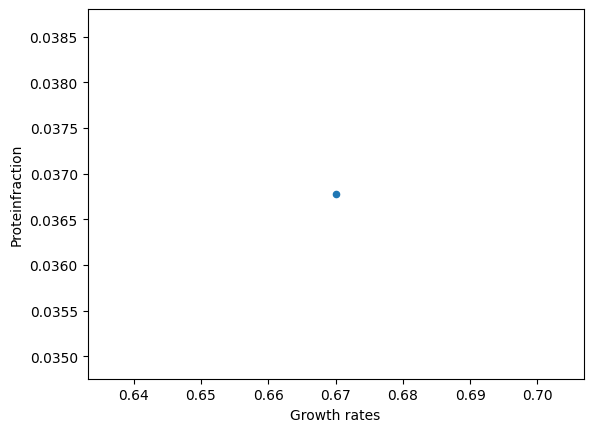

In [44]:
# analyze RNA polymerase abundances
# rnap_genes = ['b3988', 'b3987', 'b3295', 'b3067', 'b2741', 'b3202', 'b3649', 'b2573']
rnap_genes = ['b3295', 'b3987', 'b3988'] # rpoA, rpoB, rpoC -> RNA polymerase core enzyme 
# get abundaces of RNA polymerase genes (rnap_genes)
rnap_fractions_ds = (
    proteome_df.loc[rnap_genes]
    .select_dtypes(include='number')
    .sum(axis=0)
)
rnap_fractions_ds.rename('Proteinfraction', inplace=True)

# merge sum of protein abundaces with growth rate data
rnap_abundances_df = pd.concat([rnap_fractions_ds, growth_rate_df], axis=1)
rnap_abundances_df

# print as scatter plot
rnap_abundances_df.plot.scatter(x='Growth rates', y='Proteinfraction')

# Analyze proteome of E. coli core model


## Load model

In [45]:
model = cobra.io.read_sbml_model('../Models/iML1515.xml')

## Protein abundance of model proteins

In [46]:
genes_in_dataset = []

for g in model.genes:
    if g.id in proteome_df.index:
        genes_in_dataset.append(g.id)
    # else:
    #     print(f'{g.id} {g.name} not in proteome data')

# extract protein abundances for genes in dataset
proteome_model_df = proteome_df.loc[genes_in_dataset]
proteome_model_df = proteome_model_df[proteome_model_df['Cellular protein location'] != 'Cell inner membrane'] # exclude inner membrane proteins


                             Protein abundance sum  Growth rates  \
SP4+TX100_avg_per_cell [fg]               0.539116          0.67   

                             Cell volume [fL]  Cell dry weight [gDW]  
SP4+TX100_avg_per_cell [fg]          2.996783           8.042167e-13  
0.5391160806780018


Text(0, 0.5, 'Model protein abundance')

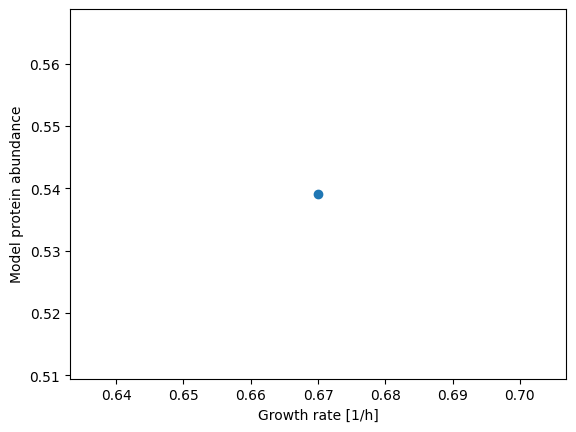

In [47]:
# sum protein abundances for each condition
proteome_model_sum_ds = proteome_model_df.select_dtypes(include='number').sum(axis=0)
proteome_model_sum_ds.rename('Protein abundance sum', inplace=True)

# merge sum of protein abundaces with growth rate data
proteome_model_sum_df = pd.concat([proteome_model_sum_ds, growth_rate_df], axis=1)
print(proteome_model_sum_df)
print(proteome_model_sum_df['Protein abundance sum'].mean())

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_model_sum_df['Growth rates'], proteome_model_sum_df['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Model protein abundance')


# Translational sector (J)

Text(0, 0.5, 'Translational protein abundance')

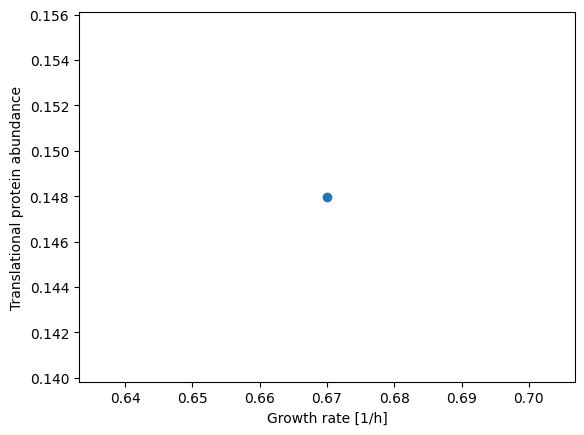

In [48]:
# sum protein abundances of proteins from COG J
# get Bnumbers associated with COG ID J from gene2cog_df
bnumbers_j = gene2cog_df.loc[gene2cog_df['COG ID'] == 'J'].index.to_list()

# sum protein abundances of translational protein sector
proteome_sum_j = proteome_df.loc[bnumbers_j].select_dtypes(include='number').sum(axis=0)
proteome_sum_j.rename('Protein abundance sum', inplace=True)

# merge with growth rates
proteome_sum_j_df = pd.concat([proteome_sum_j, growth_rate_df], axis=1)

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_sum_j_df['Growth rates'], proteome_sum_j_df['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Translational protein abundance')

## Merge translational and model protein sector 

                             Protein abundance sum  Growth rates  \
SP4+TX100_avg_per_cell [fg]               0.687086          0.67   

                             Cell volume [fL]  Cell dry weight [gDW]  
SP4+TX100_avg_per_cell [fg]          2.996783           8.042167e-13  


Text(0, 0.5, 'Protein abundance')

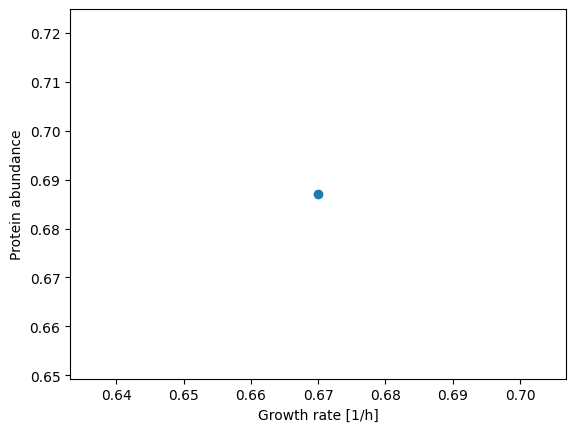

In [49]:
# Merge protein abundances
proteome_sum_merge = proteome_model_sum_df.copy()
proteome_sum_merge['Protein abundance sum'] = proteome_sum_merge['Protein abundance sum'] + proteome_sum_j_df['Protein abundance sum']
proteome_sum_merge_sort = proteome_sum_merge.sort_values(by='Growth rates')
print(proteome_sum_merge_sort)

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_sum_merge['Growth rates'], proteome_sum_merge['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Protein abundance')

In [50]:
# mean protein abundances for each condition
protein_abundance_mean = proteome_sum_merge['Protein abundance sum'].mean()
print(f'Mean total protein abundance: {round(protein_abundance_mean, 4)} g/gDW')

Mean total protein abundance: 0.6871 g/gDW


## Unused Protein Sector

In [51]:
#linear relation growth rate and protein abundance
protein_vs_mu = linregress(x=proteome_sum_merge['Growth rates'], y = proteome_sum_merge['Protein abundance sum'])

/home/claud/anaconda3/envs/DFBA_PAM/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/claud/anaconda3/envs/DFBA_PAM/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/claud/anaconda3/envs/DFBA_PAM/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


Text(0, 0.5, 'Protein abundance')

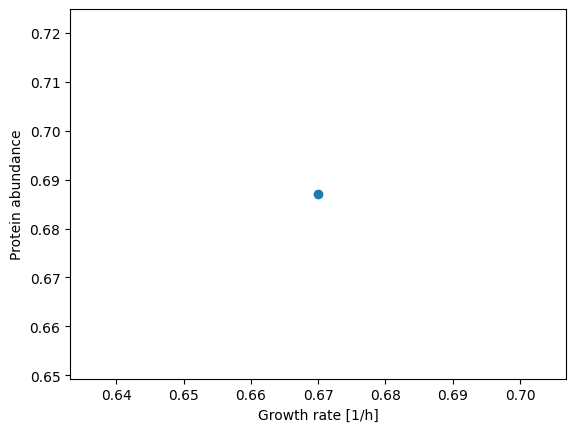

In [52]:
slope = protein_vs_mu.slope
intercept = protein_vs_mu.intercept

y= [intercept + slope*mu for mu in proteome_sum_merge['Growth rates']]
#inverse relation is the fraction of unused proteins to fill up the protein space
y2 = [intercept - slope*mu for mu in proteome_sum_merge['Growth rates']]

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.plot(proteome_sum_merge['Growth rates'],y)
ax.plot(proteome_sum_merge['Growth rates'],y2)
ax.scatter(proteome_sum_merge['Growth rates'], proteome_sum_merge['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Protein abundance')

In [53]:
print(f'Max total protein abundance: {round(proteome_sum_merge["Protein abundance sum"].mean(), 5)} g/gDW')
print('Unused enzymes at zero growth: ', round(proteome_sum_merge['Protein abundance sum']-intercept,4), ' g/gDW')
print('Change in unused enzymes with increasing growth rate: ', -round(slope,4), ' g/gDW/h')

Max total protein abundance: 0.68709 g/gDW
Unused enzymes at zero growth:  SP4+TX100_avg_per_cell [fg]   NaN
Name: Protein abundance sum, dtype: float64  g/gDW
Change in unused enzymes with increasing growth rate:  nan  g/gDW/h
